In [1]:
# 导入所有需要的包
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

# 设置图形显示参数
sc.settings.verbosity = 3          # 显示详细运行信息
sc.settings.set_figure_params(dpi=80, facecolor='white')

# 下载 PBMC 3k 数据集（约 6MB，Scanpy 官方内置教程数据）
# PBMC = 外周血单核细胞，是单细胞分析最经典的练手数据集
adata = sc.datasets.pbmc3k()

# 看一下数据的基本结构
print(adata)

try downloading from url
https://falexwolf.de/data/pbmc3k_raw.h5ad
... this may take a while but only happens once


  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


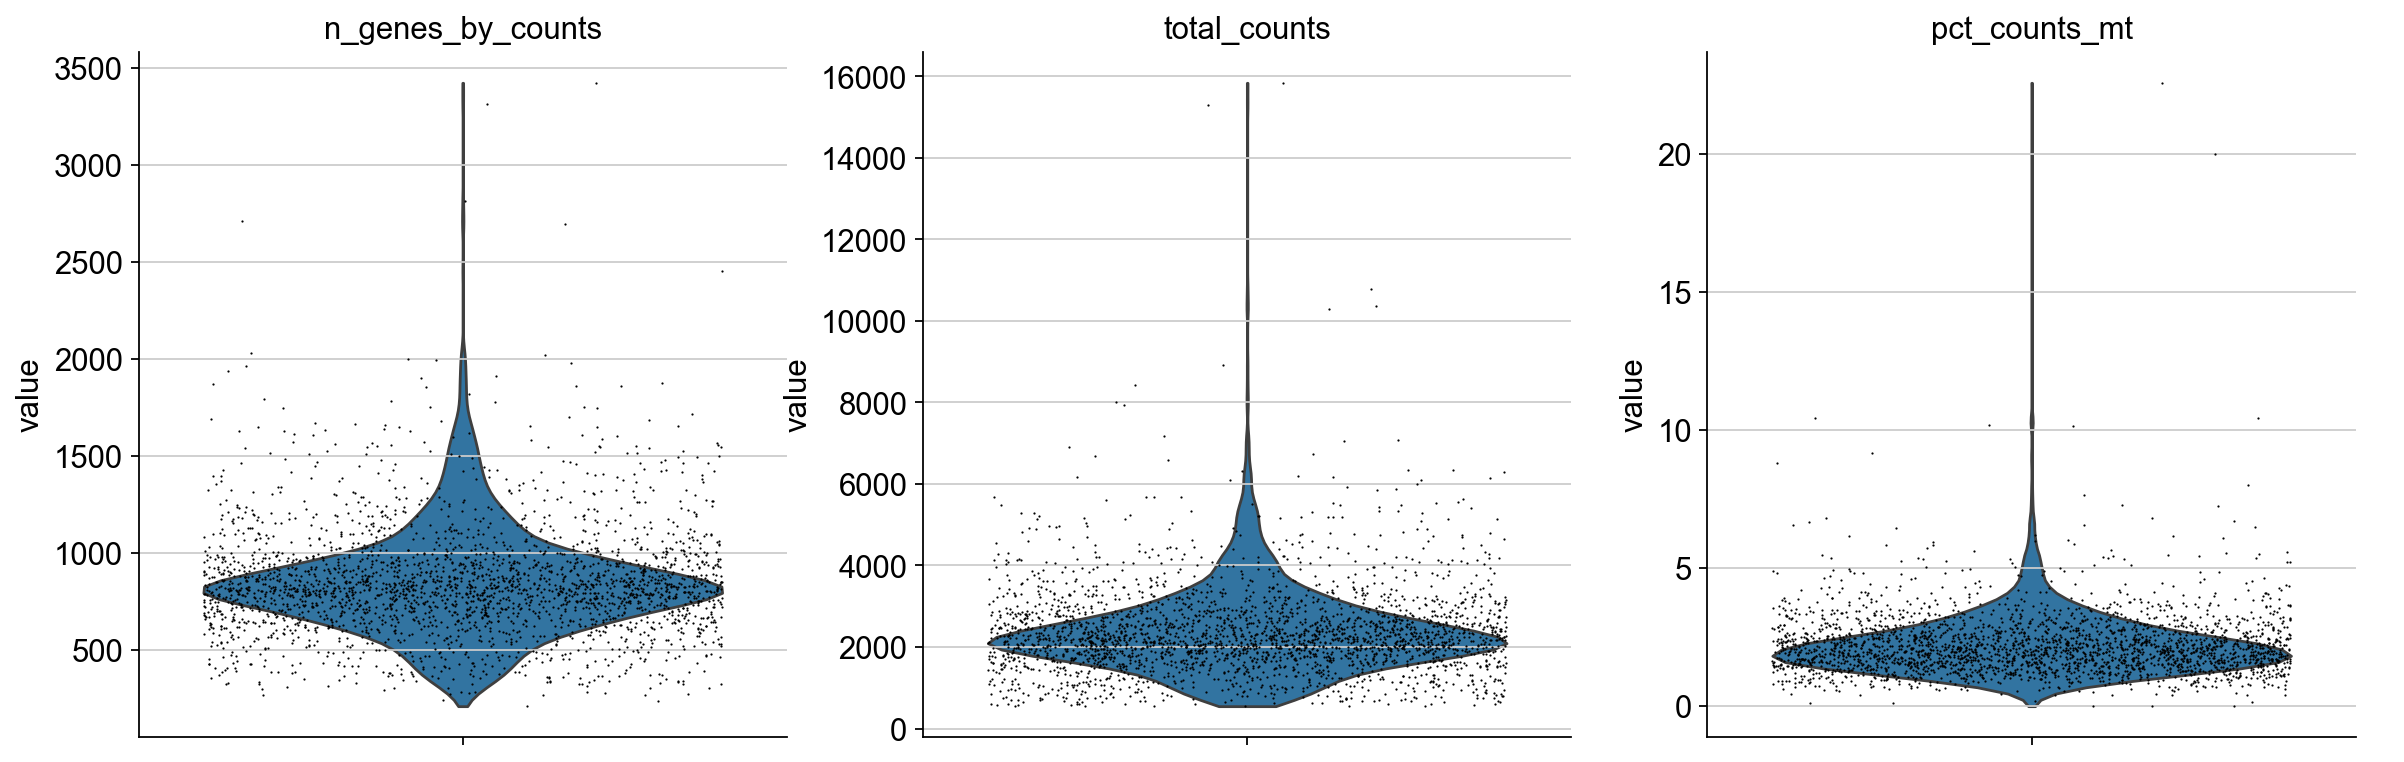

In [2]:
# ── 质量控制 Quality Control ──────────────────────────────
# 单细胞数据有很多"坏细胞"：死细胞、空液滴、双细胞
# 需要先过滤掉，否则后续分析会被干扰

# 标注线粒体基因（基因名以 MT- 开头）
# 线粒体基因比例高 → 细胞可能正在凋亡（坏细胞）
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# 计算每个细胞的QC指标
sc.pp.calculate_qc_metrics(
    adata, 
    qc_vars=['mt'],      # 用线粒体基因做QC
    percent_top=None, 
    log1p=False, 
    inplace=True
)

# 可视化QC指标分布，决定过滤阈值
sc.pl.violin(adata, 
             ['n_genes_by_counts',    # 每个细胞检测到的基因数
              'total_counts',          # 每个细胞总UMI数
              'pct_counts_mt'],        # 线粒体基因比例
             jitter=0.4, 
             multi_panel=True)

In [3]:
# ── 过滤低质量细胞和基因 ──────────────────────────────────
# 根据上面小提琴图的分布来设定阈值

# 过滤基因：至少在 3 个细胞里表达才保留
sc.pp.filter_genes(adata, min_cells=3)

# 过滤细胞：
# - 至少检测到 200 个基因（太少 = 空液滴）
# - 最多检测到 2500 个基因（太多 = 双细胞）
# - 线粒体比例 < 5%（太高 = 死细胞）
sc.pp.filter_cells(adata, min_genes=200)
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

print(f"过滤后：{adata.n_obs} 个细胞，{adata.n_vars} 个基因")

filtered out 19024 genes that are detected in less than 3 cells
过滤后：2638 个细胞，13714 个基因


normalizing counts per cell


D:\miniconda3\envs\scrna\Lib\site-packages\scanpy\preprocessing\_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


    finished (0:00:03)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
高变基因数量：1838 个


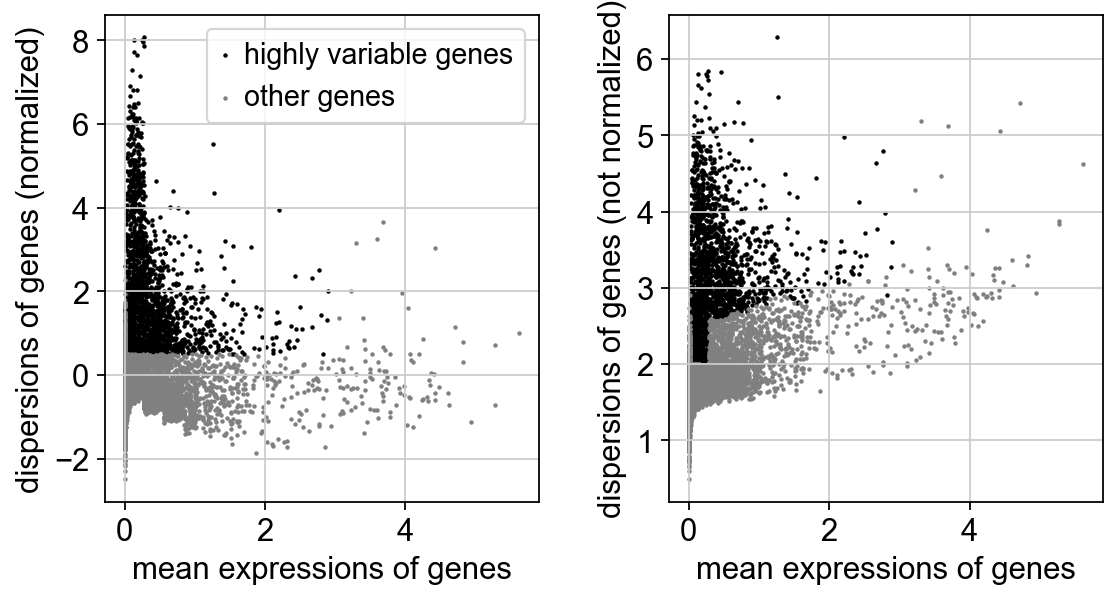

In [4]:
# ── 标准化 Normalization ──────────────────────────────────
# 每个细胞的测序深度不同（有的读了5000条，有的读了2000条）
# 需要标准化到同一基准，才能比较不同细胞之间的基因表达

# 每个细胞标准化到总计数 10000（相当于 CPM/10）
sc.pp.normalize_total(adata, target_sum=1e4)

# log1p 变换：log(x+1)
# 原因：基因表达量分布极度偏斜，少数基因表达量极高
# log变换后分布更接近正态，适合后续统计分析
sc.pp.log1p(adata)

# ── 筛选高变基因 Highly Variable Genes ───────────────────
# 不是所有基因都有信息量，只有在细胞间表达差异大的基因才有助于区分细胞类型
# 筛选最具代表性的 2000 个高变基因用于后续降维
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

print(f"高变基因数量：{adata.var.highly_variable.sum()} 个")

# 可视化高变基因
sc.pl.highly_variable_genes(adata)

regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use


D:\miniconda3\envs\scrna\Lib\site-packages\scanpy\preprocessing\_simple.py:728: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
D:\miniconda3\envs\scrna\Lib\site-packages\scanpy\preprocessing\_simple.py:666: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
D:\miniconda3\envs\scrna\Lib\site-packages\scanpy\preprocessing\_simple.py:666: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


    finished (0:00:05)
computing PCA
    with n_comps=50
    finished (0:00:01)


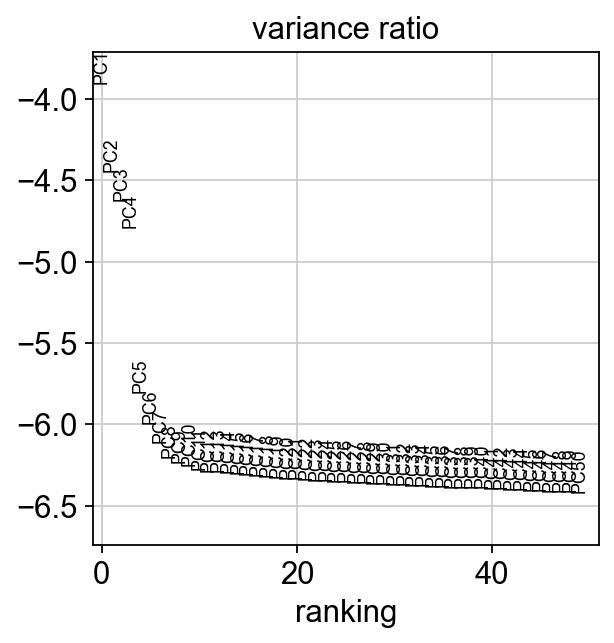

In [5]:
# ── 降维前处理 ────────────────────────────────────────────
# 只保留高变基因用于后续分析（存档原始数据）
adata.raw = adata  # 先把完整数据存档，后面画基因表达图时需要
adata = adata[:, adata.var.highly_variable]  # 只保留高变基因

# 去除批次效应中的技术噪音（回归掉总UMI数和线粒体比例的影响）
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

# 缩放到单位方差（让每个基因权重相同，避免高表达基因主导PCA）
sc.pp.scale(adata, max_value=10)

# ── PCA 主成分分析 ────────────────────────────────────────
# 1838个高变基因还是太多维，先用PCA压缩到50个主成分
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

computing neighbors
    using 'X_pca' with n_pcs = 10


D:\miniconda3\envs\scrna\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\miniconda3\envs\scrna\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\miniconda3\envs\scrna\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "D:\miniconda3\envs\scrna\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\miniconda3\envs\scrna\Lib\subprocess.

    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:26)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:03)
running Leiden clustering
    finished: found 9 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


D:\miniconda3\envs\scrna\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32858 (\N{CJK UNIFIED IDEOGRAPH-805A}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\miniconda3\envs\scrna\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


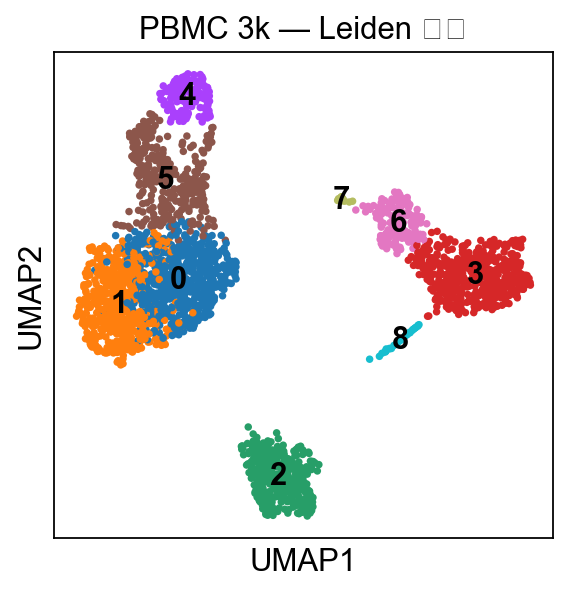

In [6]:
# ── 构建邻居图 ────────────────────────────────────────────
# 用前10个PC计算细胞之间的相似度，构建"谁和谁是邻居"的关系网络
# 这是 UMAP 和聚类的基础
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=10)

# ── UMAP 降维可视化 ───────────────────────────────────────
# 把高维数据压缩到2维平面，让我们能"看"到细胞的分布
# 相似的细胞会聚在一起，不同类型的细胞会分开
sc.tl.umap(adata)

# ── Leiden 聚类 ───────────────────────────────────────────
# 根据邻居关系自动把细胞分群
# resolution 控制分群的粗细：越大分群越多越细，越小分群越少越粗
sc.tl.leiden(adata, resolution=0.5, flavor="igraph", n_iterations=2)

# 画出 UMAP，按聚类结果上色
sc.pl.umap(adata, color=['leiden'], legend_loc='on data', title='PBMC 3k — Leiden 聚类')

D:\miniconda3\envs\scrna\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32454 (\N{CJK UNIFIED IDEOGRAPH-7EC6}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\miniconda3\envs\scrna\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32990 (\N{CJK UNIFIED IDEOGRAPH-80DE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\miniconda3\envs\scrna\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\miniconda3\envs\scrna\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26680 (\N{CJK UNIFIED IDEOGRAPH-6838}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\miniconda3\envs\scrna\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 34880 (\N{CJK UNIFIED IDEOGRAPH-8840}) missing from font(s) Arial.
  fig.canvas.print_figure(b

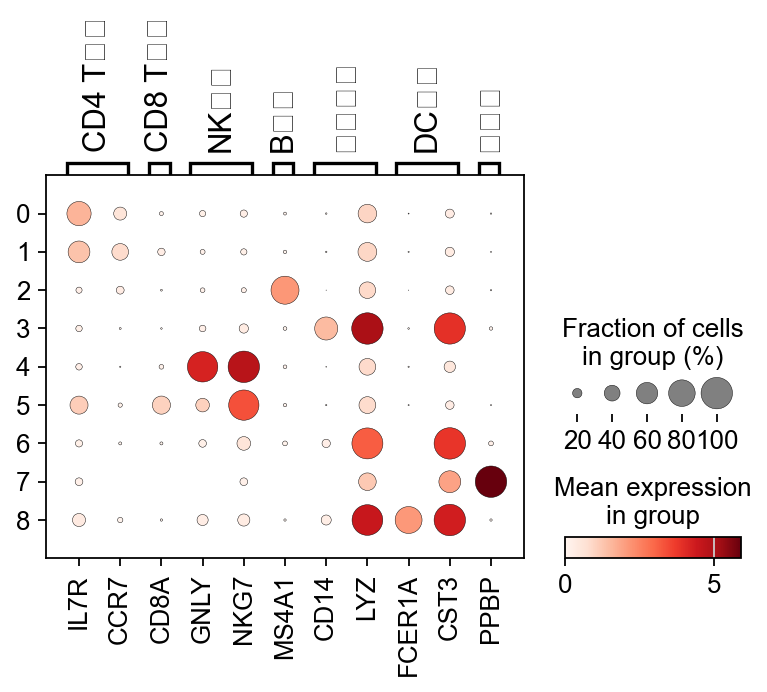

In [7]:
# ── 细胞类型标记基因可视化 ────────────────────────────────
# 用已知的标记基因来判断每个cluster是什么细胞类型
# 这是生物学知识 + 数据分析的结合点

marker_genes = {
    'CD4 T细胞':  ['IL7R', 'CCR7'],        # 辅助性T细胞
    'CD8 T细胞':  ['CD8A'],                 # 杀伤性T细胞
    'NK细胞':     ['GNLY', 'NKG7'],         # 自然杀伤细胞
    'B细胞':      ['MS4A1'],                # B淋巴细胞
    '单核细胞':   ['CD14', 'LYZ'],          # 经典单核细胞
    'DC细胞':     ['FCER1A', 'CST3'],       # 树突状细胞
    '血小板':     ['PPBP'],                 # 血小板
}

sc.pl.dotplot(adata, marker_genes, groupby='leiden', use_raw=True)

In [8]:
# 安装中文字体支持，解决乱码问题
import matplotlib
import matplotlib.pyplot as plt

# 指定使用系统自带的中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

print("字体设置完成")

字体设置完成


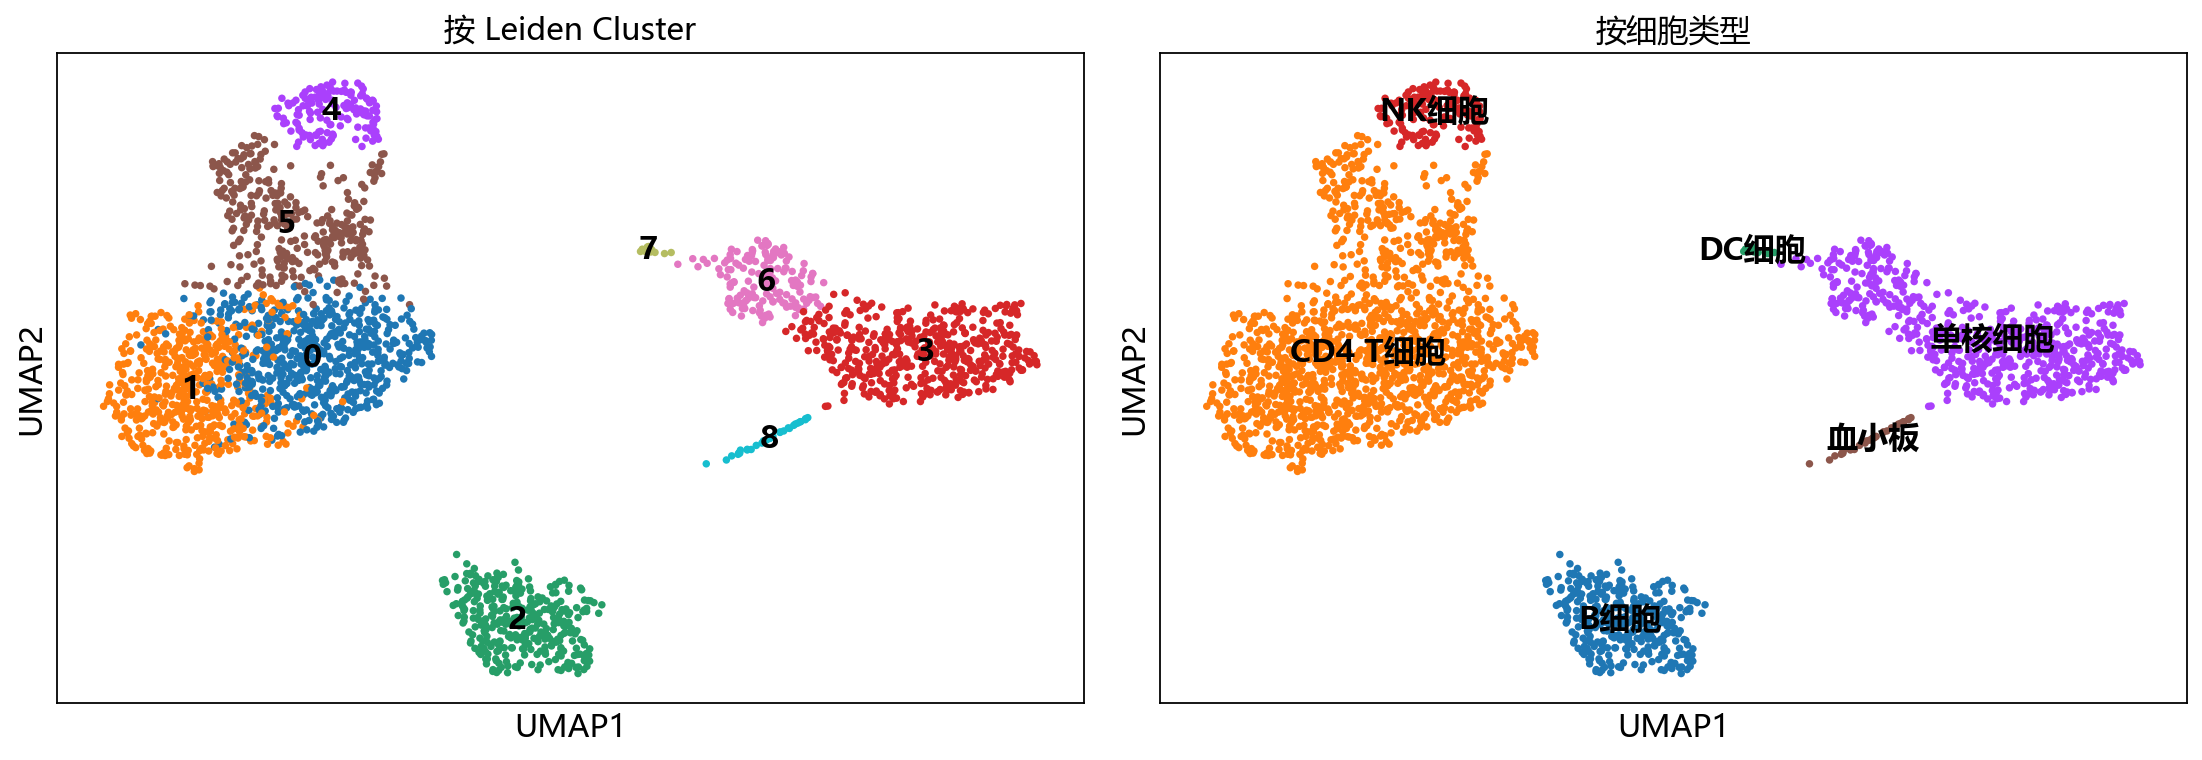

图已保存


In [9]:
# ── 细胞类型注释 ──────────────────────────────────────────
# 根据上面 dotplot 的标记基因表达，手动给每个 cluster 命名

cell_type_map = {
    '0': 'CD4 T细胞',
    '1': 'CD4 T细胞',
    '2': 'B细胞',
    '3': '单核细胞',
    '4': 'NK细胞',
    '5': 'CD4 T细胞',
    '6': '单核细胞',
    '7': 'DC细胞',
    '8': '血小板',
}

# 把注释写入 adata
adata.obs['cell_type'] = adata.obs['leiden'].map(cell_type_map)

# 画两张 UMAP 对比：左边按cluster编号，右边按细胞类型
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc.pl.umap(adata, color='leiden',    title='按 Leiden Cluster', legend_loc='on data', ax=axes[0], show=False)
sc.pl.umap(adata, color='cell_type', title='按细胞类型',         legend_loc='on data', ax=axes[1], show=False)

plt.tight_layout()
plt.savefig('PBMC3k_UMAP_annotated.png', dpi=150, bbox_inches='tight')
plt.show()
print("图已保存")